# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Shriya |
| **Role** | Person 1 — `train.csv` Audit & Time Feature Extraction |
| **Notebook** | `Shriya_Train_Core_Audit.ipynb` |

---

## Sprint 1 — Data Exploration & Audit (`train.csv`)


SPRINT 1 TASKS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess

print("Libraries loaded")

Libraries loaded


In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))  # go to main project folder

In [3]:
from shared.data_loader import load_train, load_test, load_metadata, load_weather_train, load_weather_test

Loading data

In [4]:
dtypes = {
    'building_id': np.int16,
    'meter': np.int8,
    'meter_reading': np.float32
}

train = pd.read_csv(
     'train.csv',
    dtype=dtypes,
    parse_dates=['timestamp']

)


print("Data loaded successfully")

Data loaded successfully


UNDERSTANDING DATA

In [5]:
print(train.shape)
train.head()
train.info()

(20216100, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   building_id    int16         
 1   meter          int8          
 2   timestamp      datetime64[ns]
 3   meter_reading  float32       
dtypes: datetime64[ns](1), float32(1), int16(1), int8(1)
memory usage: 289.2 MB



DATA RANGE

In [6]:
print(train['timestamp'].min())
print(train['timestamp'].max())

2016-01-01 00:00:00
2016-12-31 23:00:00


In [7]:
print("Start date:", train['timestamp'].min())
print("End date:", train['timestamp'].max())

Start date: 2016-01-01 00:00:00
End date: 2016-12-31 23:00:00



COLUMNS

In [8]:
print(train.columns)

Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='object')


In [9]:
train.columns = train.columns.str.strip().str.lower()
print(train.columns)

Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='object')


BUILDINGS AND METERS

In [10]:
print("Unique buildings:", train['building_id'].nunique())
print("Unique meters:", train['meter'].nunique())

Unique buildings: 1449
Unique meters: 4


ZERO AND NEGATIVE VALUES

In [11]:
print("Zero readings:", (train['meter_reading'] == 0).sum())
print("Negative readings:", (train['meter_reading'] < 0).sum())

Zero readings: 1873976
Negative readings: 0


RAW DISTRIBUTION

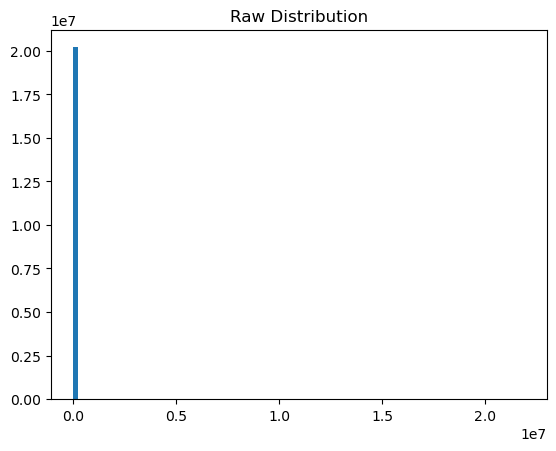

In [12]:
import matplotlib.pyplot as plt

plt.hist(train['meter_reading'], bins=100)
plt.title("Raw Distribution")
plt.show()

LOG DISTRIBUTION

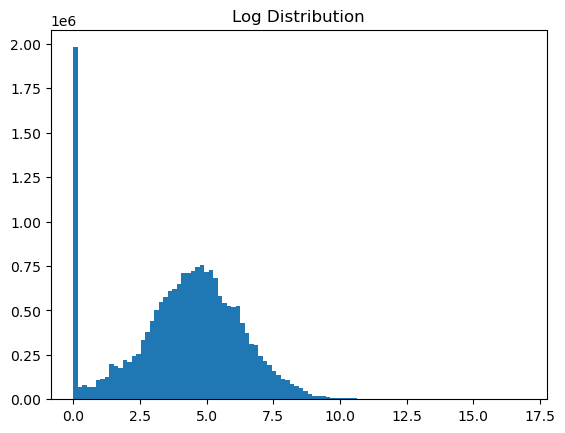

In [13]:
import numpy as np

plt.hist(np.log1p(train['meter_reading']), bins=100)
plt.title("Log Distribution")
plt.show()


METER COMBINATIONS

0 → Electricity, 1 → Chilled Water, 2 → Steam, 3 → Hot Water

In [14]:
meter_counts = train.groupby('building_id')['meter'].nunique()
print(meter_counts.value_counts())

meter
1    875
3    331
2    230
4     13
Name: count, dtype: int64



SUMMARY

Dataset contains 8165364 rows and 4 columns ('building_id', 'meter', 'timestamp', 'meter_reading')
Memory Usage: 116.8 MB
Covers time period from 2016-01-01 to 2016-05-31.
Contains 1441 unique buildings and 4 meter types.
Large number of zero readings observed (964396).
Negative readings are minimal but invalid.
Data distribution is highly skewed -makes it difficult to visually interpret patterns using the original scale. (majority of buildings use low energy, few buildings use extremely high energy)
Log transformation improved visualization - (smooth and spread out graph, we can clearly see the shape of the data, outliers are no longer dominating)
Meter combinations - most buildings are associated with only one type of meter(mostly electricity, while a smaller proportion have multiple meter types.

---

## Sprint 2 — Time Feature Extraction & Preprocessing


TIMESTAMP

In [15]:
train['timestamp'] = pd.to_datetime(train['timestamp'])


BASIC TIME FEATUIRES

day_of_week( 0 → Monday, 1 → Tuesday, 2 → Wednesday, 3 → Thursday, 4 → Friday, 5 → Saturday, 6 → Sunday)

In [16]:
train['hour'] = train['timestamp'].dt.hour
train['day_of_week'] = train['timestamp'].dt.dayofweek
train['month'] = train['timestamp'].dt.month
train['day_of_year'] = train['timestamp'].dt.dayofyear


WEEKEND FEATURE

0 → Weekday (Monday to Friday), 1 → Weekend (Saturday & Sunday)

In [17]:
train['is_weekend'] = (train['day_of_week'] >= 5).astype(int)

BUSINESS HOURS

0 → Not business hours, 1 → Business hours (8 AM to 6 PM, weekdays)

In [18]:
train['is_business_hours'] = (
    (train['hour'] >= 8) & 
    (train['hour'] <= 18) & 
    (train['day_of_week'] < 5)
).astype(int)
print(train[['hour','day_of_week','month']].head())

   hour  day_of_week  month
0     0            4      1
1     0            4      1
2     0            4      1
3     0            4      1
4     0            4      1


SEASON FEATURE

0 → Winter (Dec, Jan, Feb), 1 → Spring (Mar, Apr, May), 2 → Summer (Jun, Jul, Aug), 3 → Autumn (Sep, Oct, Nov)

In [19]:
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # winter
    elif month in [3, 4, 5]:
        return 1  # spring
    elif month in [6, 7, 8]:
        return 2  # summer
    else:
        return 3  # autumn

train['season'] = train['month'].apply(get_season)

print(train[['month', 'season', 'hour', 'day_of_week', 'is_business_hours']].head())

   month  season  hour  day_of_week  is_business_hours
0      1       0     0            4                  0
1      1       0     0            4                  0
2      1       0     0            4                  0
3      1       0     0            4                  0
4      1       0     0            4                  0


LOG TRANSFORMATION

In [20]:
import numpy as np

train['log_meter_reading'] = np.log1p(train['meter_reading'])

In [21]:
train[['hour','day_of_week','month','is_weekend','is_business_hours','season','log_meter_reading']].head()

,hour,day_of_week,month,is_weekend,is_business_hours,season,log_meter_reading
0,0,4,1,0,0,0,0.0
1,0,4,1,0,0,0,0.0
2,0,4,1,0,0,0,0.0
3,0,4,1,0,0,0,0.0
4,0,4,1,0,0,0,0.0


BEFORE

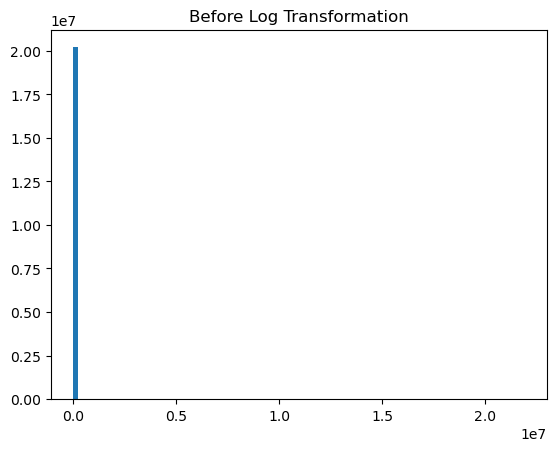

In [22]:
import matplotlib.pyplot as plt

plt.hist(train['meter_reading'], bins=100)
plt.title("Before Log Transformation")
plt.show()


AFTER

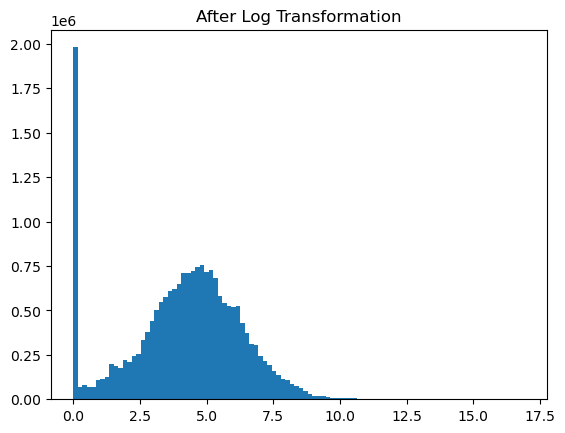

In [23]:
plt.hist(train['log_meter_reading'], bins=100)
plt.title("After Log Transformation")
plt.show()

In [24]:
train.head()

,building_id,meter,timestamp,meter_reading,hour,day_of_week,month,day_of_year,is_weekend,is_business_hours,season,log_meter_reading
0,0,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
1,1,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
2,2,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
3,3,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
4,4,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0


APPLY FEATURES TO MERGED FILES & SAVE

In [26]:
import os

data_dir = '/content/data_processed' if os.path.exists('/content') else os.path.join('..', 'data_processed')

# ── merged_train.csv ──────────────────────────────────────────────────────────
merged_train = pd.read_csv(os.path.join(data_dir, 'merged_train.csv'), parse_dates=['timestamp'])

merged_train['hour']              = merged_train['timestamp'].dt.hour
merged_train['day_of_week']       = merged_train['timestamp'].dt.dayofweek
merged_train['month']             = merged_train['timestamp'].dt.month
merged_train['day_of_year']       = merged_train['timestamp'].dt.dayofyear
merged_train['season']            = merged_train['month'].apply(get_season)
merged_train['is_weekend']        = (merged_train['day_of_week'] >= 5).astype(int)
merged_train['is_business_hours'] = (
    (merged_train['hour'] >= 8) & (merged_train['hour'] <= 18) &
    (merged_train['day_of_week'] < 5)
).astype(int)
merged_train['log_meter_reading'] = np.log1p(merged_train['meter_reading'])

# ── merged_test.csv ───────────────────────────────────────────────────────────
merged_test = pd.read_csv(os.path.join(data_dir, 'merged_test.csv'), parse_dates=['timestamp'])

merged_test['hour']              = merged_test['timestamp'].dt.hour
merged_test['day_of_week']       = merged_test['timestamp'].dt.dayofweek
merged_test['month']             = merged_test['timestamp'].dt.month
merged_test['day_of_year']       = merged_test['timestamp'].dt.dayofyear
merged_test['season']            = merged_test['month'].apply(get_season)
merged_test['is_weekend']        = (merged_test['day_of_week'] >= 5).astype(int)
merged_test['is_business_hours'] = (
    (merged_test['hour'] >= 8) & (merged_test['hour'] <= 18) &
    (merged_test['day_of_week'] < 5)
).astype(int)
# No log_meter_reading for test — test set has no meter_reading column

# ── Save ──────────────────────────────────────────────────────────────────────
merged_train.to_csv(os.path.join(data_dir, 'merged_train.csv'), index=False)
merged_test.to_csv(os.path.join(data_dir, 'merged_test.csv'),   index=False)

print("merged_train saved:", merged_train.shape, "| new cols:", [c for c in merged_train.columns if c not in ['building_id','meter','timestamp','meter_reading','site_id','primary_use','square_feet','year_built','floor_count','air_temperature','cloud_coverage','dew_temperature','precip_depth_1_hr','sea_level_pressure','wind_direction','wind_speed']])
print("merged_test  saved:", merged_test.shape,  "| new cols:", [c for c in merged_test.columns  if c not in ['row_id','building_id','meter','timestamp','site_id','primary_use','square_feet','year_built','floor_count','air_temperature','cloud_coverage','dew_temperature','precip_depth_1_hr','sea_level_pressure','wind_direction','wind_speed']])

merged_train saved: (20216100, 24) | new cols: ['hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours', 'log_meter_reading']
merged_test  saved: (41697600, 23) | new cols: ['hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours']


---

## Sprint 3 — Model Pipeline Contribution

Loading raw files...
train_raw: (20216100, 4)
meta     : (1449, 6)
weather  : (139773, 9)

Running Wahid building metadata preprocessing...
Wahid preprocessing done. Meta shape: (1449, 22)


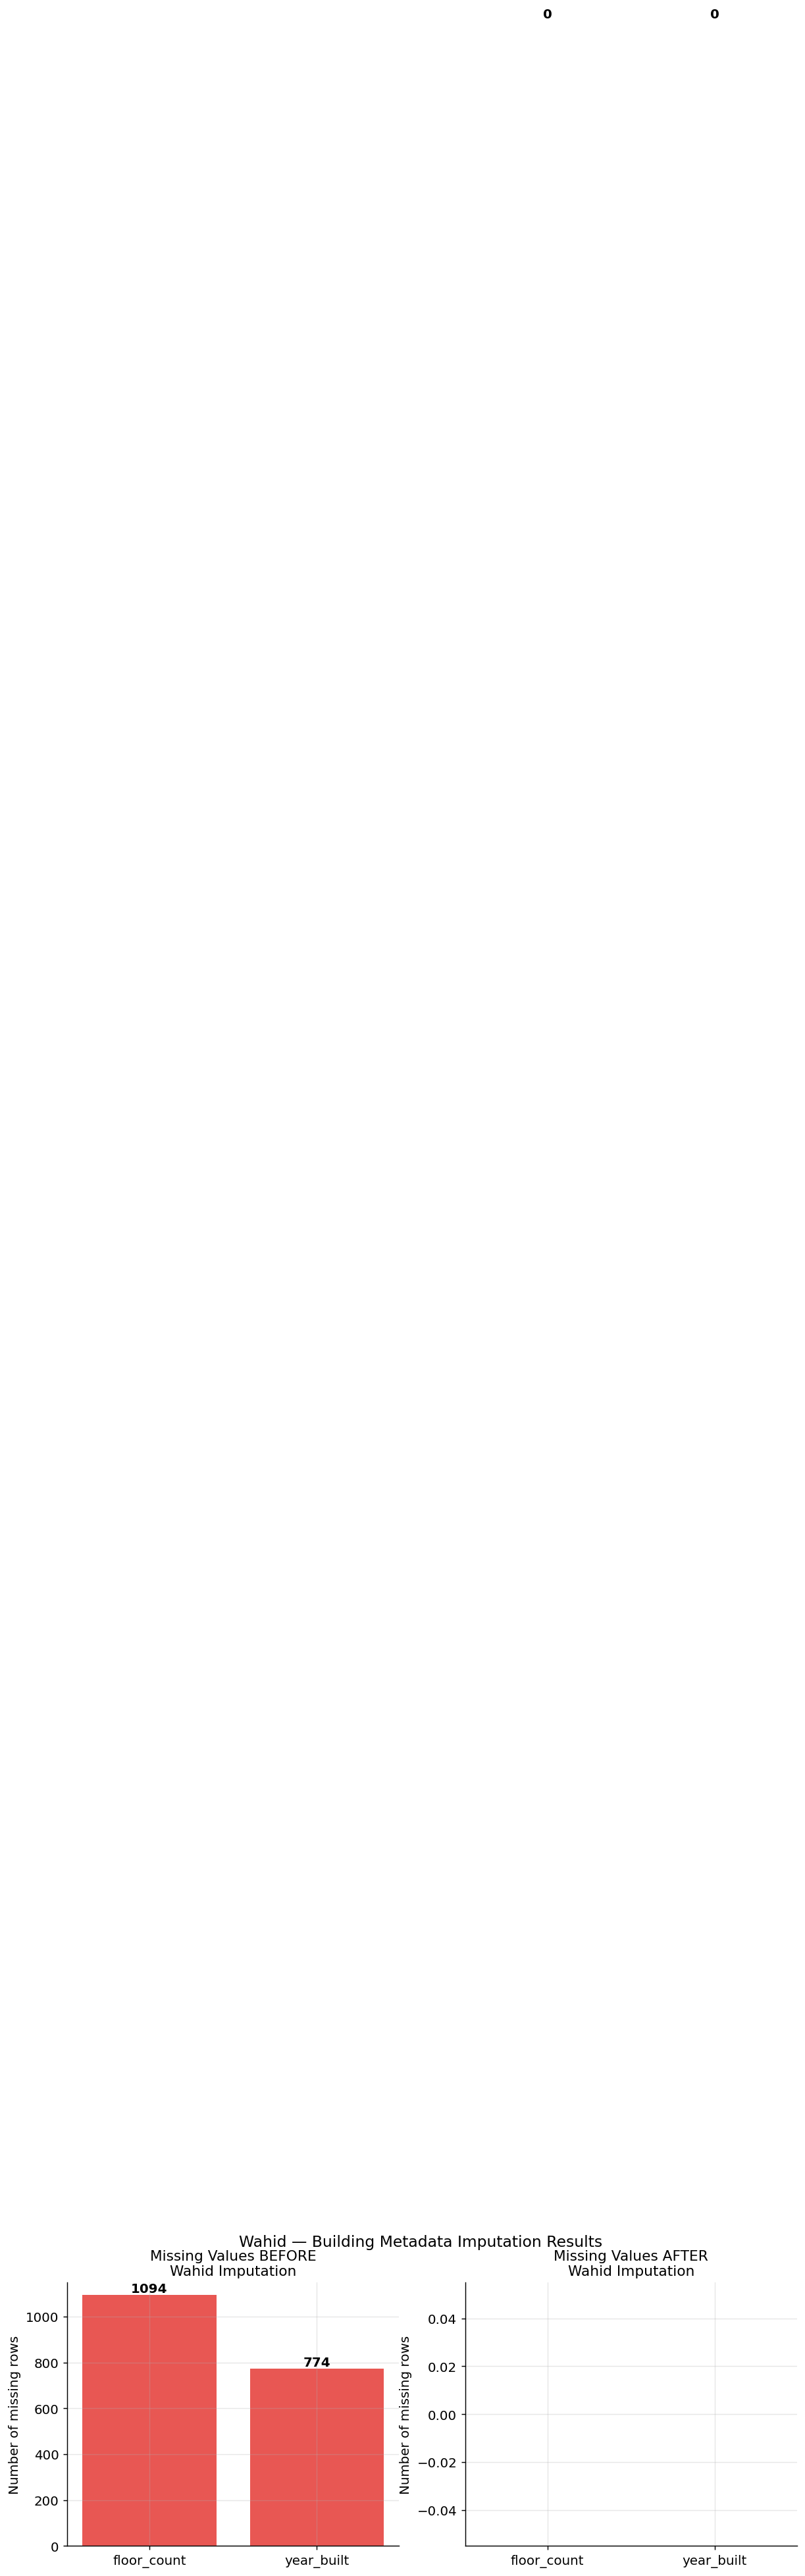

Wahid imputation plot saved. Now merging data...

Merging...
Merged shape: (20216100, 32)

Adding Shivalika time features...
Adding weather features...
Adding lag and rolling features — takes a few minutes...

Plotting Shivalika time series patterns...


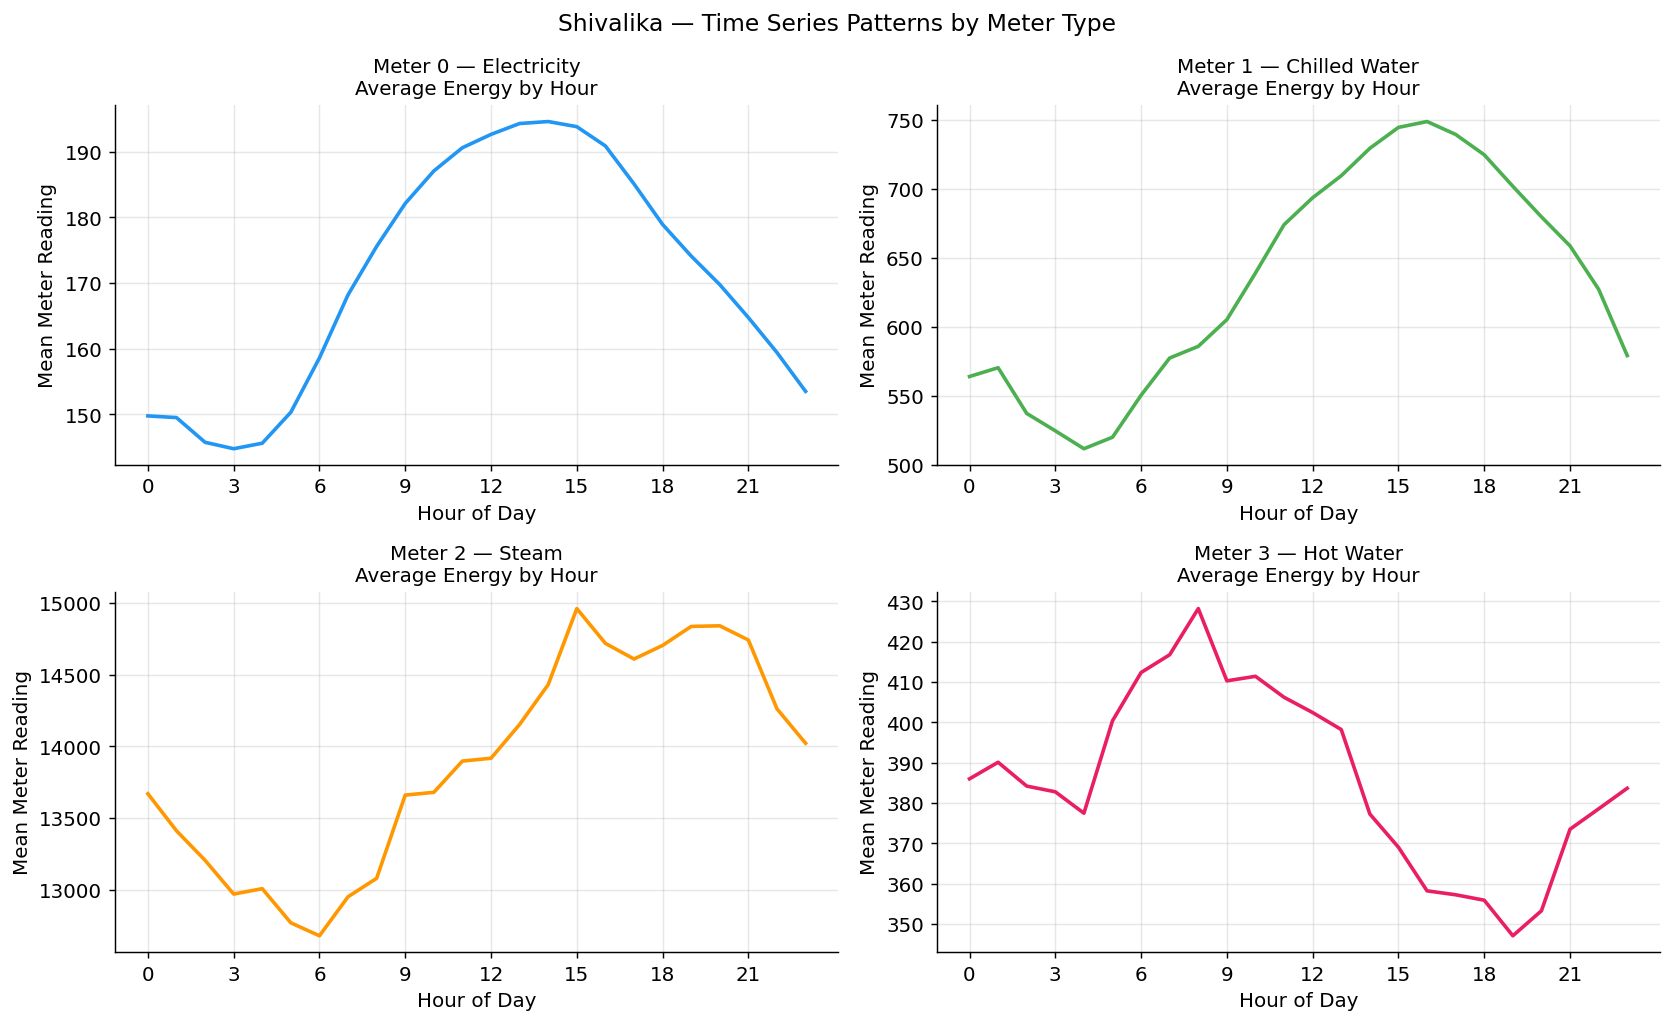

Shivalika time series plot saved. Now splitting data...

Splitting and saving...
Train saved: (16172880, 49)
Val saved  : (4043220, 49)

Preparing model features...
X_train: (16172880, 45)
X_test : (4043220, 45)
Ayan RMSLE function loaded.

Computing baseline...
Baseline RMSLE: 1.4649

Training LightGBM (Shivalika)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.597567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3558
[LightGBM] [Info] Number of data points in the train set: 16172880, number of used features: 44
[LightGBM] [Info] Start training from score 4.129124
LightGBM RMSLE: 0.5581
Plotting LightGBM scatter plot...


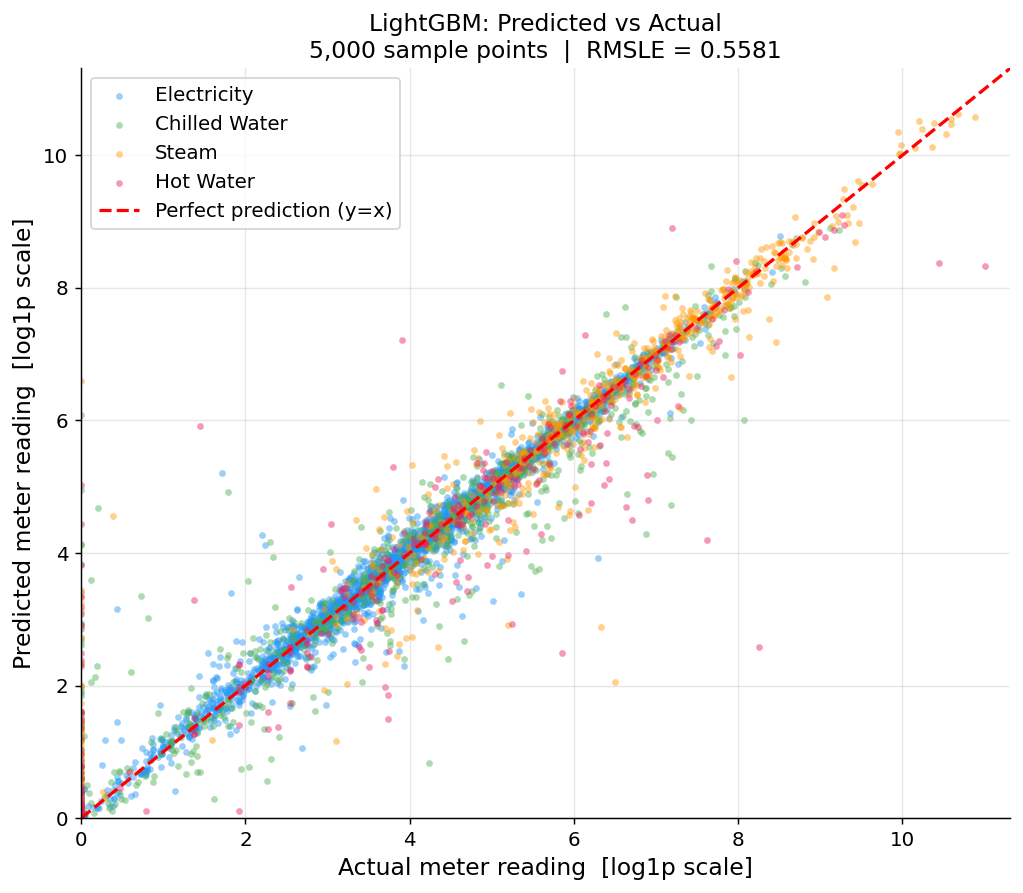

Scatter plot saved. Now starting Random Forest — please wait 5-10 mins...

Training Random Forest (Ayan)...


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 11
})

METER_NAMES  = {0:'Electricity', 1:'Chilled Water', 2:'Steam', 3:'Hot Water'}
METER_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#E91E63'}

# Paths
if os.path.exists('/content'):
    raw_dir  = '/content/data/ashrae-energy-prediction'
    data_dir = '/content/data_processed'
    out_dir  = '/content/outputs'
else:
    raw_dir  = os.path.join('..', 'data', 'ashrae-energy-prediction')
    data_dir = os.path.join('..', 'data_processed')
    out_dir  = os.path.join('..', 'outputs')

# ══════════════════════════════════════════════════════════════
# STEP 1 — LOAD RAW FILES
# ══════════════════════════════════════════════════════════════
print('Loading raw files...')
train_raw = pd.read_csv(os.path.join(raw_dir, 'train.csv'))
meta      = pd.read_csv(os.path.join(raw_dir, 'building_metadata.csv'))
weather   = pd.read_csv(os.path.join(raw_dir, 'weather_train.csv'))
print('train_raw:', train_raw.shape)
print('meta     :', meta.shape)
print('weather  :', weather.shape)

# ══════════════════════════════════════════════════════════════
# STEP 2 — WAHID'S BUILDING METADATA PREPROCESSING
# ══════════════════════════════════════════════════════════════
print('\nRunning Wahid building metadata preprocessing...')

meta['missing_floor_count_flag'] = meta['floor_count'].isna().astype(int)

meta['sqft_bin'] = pd.qcut(meta['square_feet'], q=5, duplicates='drop')
meta['floor_count'] = meta['floor_count'].fillna(
    meta.groupby(['primary_use','site_id','sqft_bin'], observed=True)['floor_count'].transform('median')
)
meta['floor_count'] = meta['floor_count'].fillna(
    meta.groupby(['primary_use','sqft_bin'], observed=True)['floor_count'].transform('median')
)
meta['floor_count'] = meta['floor_count'].fillna(
    meta.groupby('sqft_bin', observed=True)['floor_count'].transform('median')
)
meta['floor_count'] = meta['floor_count'].fillna(meta['floor_count'].median())
meta['floor_count'] = meta['floor_count'].round().astype(int)
meta = meta.drop(columns=['sqft_bin'])

meta['year_built'] = meta['year_built'].fillna(
    meta.groupby(['primary_use','site_id'], observed=True)['year_built'].transform('median')
)
meta['year_built'] = meta['year_built'].fillna(
    meta.groupby('primary_use', observed=True)['year_built'].transform('median')
)
meta['year_built'] = meta['year_built'].fillna(meta['year_built'].median())

meta['building_age']    = 2016 - meta['year_built']
meta['log_square_feet'] = np.log1p(meta['square_feet'])
meta = pd.get_dummies(meta, columns=['primary_use'], prefix='use')
meta.drop(columns=['year_built','square_feet'], inplace=True)

print('Wahid preprocessing done. Meta shape:', meta.shape)

# ── WAHID PLOT — Missing values before vs after imputation ───
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

before = {'floor_count': 1094, 'year_built': 774}
after  = {'floor_count': 0,    'year_built': 0}

axes[0].bar(before.keys(), before.values(), color='#E53935', alpha=0.85)
axes[0].set_title('Missing Values BEFORE\nWahid Imputation', fontsize=12)
axes[0].set_ylabel('Number of missing rows')
for i, (k, v) in enumerate(before.items()):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].bar(after.keys(), after.values(), color='#43A047', alpha=0.85)
axes[1].set_title('Missing Values AFTER\nWahid Imputation', fontsize=12)
axes[1].set_ylabel('Number of missing rows')
for i, (k, v) in enumerate(after.items()):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Wahid — Building Metadata Imputation Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'wahid_imputation_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Wahid imputation plot saved. Now merging data...')

# ══════════════════════════════════════════════════════════════
# STEP 3 — MERGE
# ══════════════════════════════════════════════════════════════
print('\nMerging...')
train_raw['timestamp'] = pd.to_datetime(train_raw['timestamp'], format='mixed')
weather['timestamp']   = pd.to_datetime(weather['timestamp'],   format='mixed')

df = train_raw.merge(meta, on='building_id', how='left')
df = df.merge(weather, on=['site_id','timestamp'], how='left')
print('Merged shape:', df.shape)

# ══════════════════════════════════════════════════════════════
# STEP 4 — SHIVALIKA'S TIME FEATURES
# ══════════════════════════════════════════════════════════════
print('\nAdding Shivalika time features...')
df['hour']              = df['timestamp'].dt.hour
df['day_of_week']       = df['timestamp'].dt.dayofweek
df['is_weekend']        = df['day_of_week'].isin([5,6]).astype(int)
df['month']             = df['timestamp'].dt.month
df['day_of_year']       = df['timestamp'].dt.dayofyear
df['season']            = df['month'].map({12:0,1:0,2:0,3:1,4:1,5:1,
                                            6:2,7:2,8:2,9:3,10:3,11:3})
df['is_business_hours'] = df['hour'].between(8,18).astype(int)

# ══════════════════════════════════════════════════════════════
# STEP 5 — WEATHER FEATURES
# ══════════════════════════════════════════════════════════════
print('Adding weather features...')
for col in ['air_temperature','dew_temperature','wind_speed',
            'cloud_coverage','sea_level_pressure',
            'wind_direction','precip_depth_1_hr']:
    df[col] = df[col].fillna(df[col].median())

df['precip_was_missing']     = df['precip_depth_1_hr'].isna().astype(int)
df['relative_humidity']      = 100 - 5*(df['air_temperature'] - df['dew_temperature'])
df['temp_diff_from_comfort'] = (df['air_temperature'] - 21).abs()

# ══════════════════════════════════════════════════════════════
# STEP 6 — SHIVALIKA'S LAG AND ROLLING FEATURES
# ══════════════════════════════════════════════════════════════
print('Adding lag and rolling features — takes a few minutes...')
df = df.sort_values(['building_id','meter','timestamp'])

for lag in [24, 72, 168]:
    df[f'lag_{lag}h'] = (
        df.groupby(['building_id','meter'])['meter_reading']
        .shift(lag).fillna(0)
    )

df['rolling_mean_24h'] = (
    df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(24, min_periods=1).mean()).fillna(0)
)
df['rolling_std_24h'] = (
    df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(24, min_periods=1).std()).fillna(0)
)
df['rolling_mean_168h'] = (
    df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(168, min_periods=1).mean()).fillna(0)
)
df['log_meter_reading'] = np.log1p(df['meter_reading'])

# ── SHIVALIKA PLOT — Average energy by hour per meter type ───
print('\nPlotting Shivalika time series patterns...')
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
for i, m_id in enumerate([0,1,2,3]):
    subset = df[df['meter'] == m_id]
    if len(subset) == 0:
        continue
    hourly = subset.groupby('hour')['meter_reading'].mean()
    axes[i].plot(hourly.index, hourly.values, color=METER_COLORS[m_id], lw=2)
    axes[i].set_title(f'Meter {m_id} — {METER_NAMES[m_id]}\nAverage Energy by Hour', fontsize=11)
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('Mean Meter Reading')
    axes[i].set_xticks(range(0,24,3))
plt.suptitle('Shivalika — Time Series Patterns by Meter Type', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'shivalika_time_series_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Shivalika time series plot saved. Now splitting data...')

# ══════════════════════════════════════════════════════════════
# STEP 7 — TRAIN / VAL SPLIT AND SAVE
# ══════════════════════════════════════════════════════════════
print('\nSplitting and saving...')
df = df.sort_values('timestamp').reset_index(drop=True)
split    = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
val_df   = df.iloc[split:].copy()

train_df.to_csv(os.path.join(data_dir, 'final_train_with_features.csv'), index=False)
val_df.to_csv(  os.path.join(data_dir, 'final_val_with_features.csv'),   index=False)
print(f'Train saved: {train_df.shape}')
print(f'Val saved  : {val_df.shape}')

# ══════════════════════════════════════════════════════════════
# STEP 8 — PREPARE FEATURES
# ══════════════════════════════════════════════════════════════
print('\nPreparing model features...')
drop_cols = [c for c in ['meter_reading','log_meter_reading','timestamp','building_id']
             if c in train_df.columns]

X_train   = train_df.drop(columns=drop_cols)
y_train   = train_df['log_meter_reading']
X_test    = val_df.drop(columns=drop_cols)
X_test    = X_test.reindex(columns=X_train.columns, fill_value=0)
y_true    = val_df['meter_reading'].values
meter_col = val_df['meter'].values
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

# ══════════════════════════════════════════════════════════════
# STEP 9 — AYAN'S RMSLE FUNCTION
# ══════════════════════════════════════════════════════════════
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

print('Ayan RMSLE function loaded.')

# ══════════════════════════════════════════════════════════════
# STEP 10 — BASELINE (Ayan Sprint 2)
# ══════════════════════════════════════════════════════════════
print('\nComputing baseline...')
train_df['_hour'] = train_df['timestamp'].dt.hour
train_df['_dow']  = train_df['timestamp'].dt.dayofweek
val_df['_hour']   = val_df['timestamp'].dt.hour
val_df['_dow']    = val_df['timestamp'].dt.dayofweek

baseline_median = (
    train_df.groupby(['building_id','meter','_hour','_dow'])['meter_reading']
    .median().reset_index().rename(columns={'meter_reading':'pred'})
)
test_b = val_df[['building_id','meter','_hour','_dow']].copy()
test_b = test_b.merge(baseline_median, on=['building_id','meter','_hour','_dow'], how='left')
test_b['pred']  = test_b['pred'].fillna(train_df['meter_reading'].median())
y_pred_baseline = test_b['pred'].values
rmsle_baseline  = rmsle(y_true, y_pred_baseline)
print(f'Baseline RMSLE: {rmsle_baseline:.4f}')

# ══════════════════════════════════════════════════════════════
# STEP 11 — LIGHTGBM (Shivalika)
# ══════════════════════════════════════════════════════════════
print('\nTraining LightGBM (Shivalika)...')
y_train_log = np.log1p(train_df['meter_reading'])
lgbm_model  = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=31, random_state=42, n_jobs=-1
)
lgbm_model.fit(X_train, y_train_log)
y_pred_lgbm = np.expm1(lgbm_model.predict(X_test))
rmsle_lgbm  = rmsle(y_true, y_pred_lgbm)
print(f'LightGBM RMSLE: {rmsle_lgbm:.4f}')

# ── PLOT IMMEDIATELY after LightGBM — Scatter plot ───────────
print('Plotting LightGBM scatter plot...')
rng        = np.random.default_rng(seed=42)
idx        = rng.choice(len(y_true), size=5000, replace=False)
actual_log = np.log1p(y_true[idx])
pred_log   = np.log1p(y_pred_lgbm[idx])
m_sample   = meter_col[idx]

fig, ax = plt.subplots(figsize=(8, 7))
for m_id, m_name in METER_NAMES.items():
    mask = m_sample == m_id
    if mask.sum() == 0:
        continue
    ax.scatter(actual_log[mask], pred_log[mask],
               c=METER_COLORS[m_id], label=m_name, alpha=0.45, s=14, linewidths=0)
max_val = max(actual_log.max(), pred_log.max()) + 0.3
ax.plot([0, max_val], [0, max_val], color='red', lw=1.8,
        linestyle='--', label='Perfect prediction (y=x)')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel('Actual meter reading  [log1p scale]', fontsize=13)
ax.set_ylabel('Predicted meter reading  [log1p scale]', fontsize=13)
ax.set_title(f'LightGBM: Predicted vs Actual\n5,000 sample points  |  RMSLE = {rmsle_lgbm:.4f}',
             fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'scatter_lightgbm_predicted_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plot saved. Now starting Random Forest — please wait 5-10 mins...')

# ══════════════════════════════════════════════════════════════
# STEP 12 — RANDOM FOREST (Ayan)
# ══════════════════════════════════════════════════════════════
print('\nTraining Random Forest (Ayan)...')
rf_model = RandomForestRegressor(
    n_estimators=400, max_depth=20,
    min_samples_split=6, min_samples_leaf=4,
    max_features='log2', n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = np.expm1(rf_model.predict(X_test))
rmsle_rf  = rmsle(y_true, y_pred_rf)
print(f'Random Forest RMSLE: {rmsle_rf:.4f}')

# ── PLOT IMMEDIATELY after RF — Bar chart all 3 models ───────
print('Plotting RMSLE bar chart...')
meter_ids    = sorted(np.unique(meter_col))
meter_labels = [METER_NAMES.get(m, f'Meter {m}') for m in meter_ids]
lgbm_per_m, rf_per_m, base_per_m = [], [], []

for m_id in meter_ids:
    mask = meter_col == m_id
    lgbm_per_m.append(rmsle(y_true[mask], y_pred_lgbm[mask]))
    rf_per_m.append(  rmsle(y_true[mask], y_pred_rf[mask]))
    base_per_m.append(rmsle(y_true[mask], y_pred_baseline[mask]))

print(f'\n{"Meter":<16} {"LightGBM":>10} {"Rand Forest":>13} {"Baseline":>10}')
print('-' * 52)
for i, name in enumerate(meter_labels):
    print(f'{name:<16} {lgbm_per_m[i]:>10.4f} {rf_per_m[i]:>13.4f} {base_per_m[i]:>10.4f}')

x, w = np.arange(len(meter_labels)), 0.26
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x-w, lgbm_per_m, w, label='LightGBM (Shivalika)', color='#2196F3', alpha=0.88)
b2 = ax.bar(x,   rf_per_m,   w, label='Random Forest (Ayan)', color='#FF9800', alpha=0.88)
b3 = ax.bar(x+w, base_per_m, w, label='Baseline — median',    color='#9E9E9E', alpha=0.80)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h+0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Meter Type', fontsize=13)
ax.set_ylabel('RMSLE  (lower is better)', fontsize=13)
ax.set_title('RMSLE per Meter Type — LightGBM vs Random Forest vs Baseline', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(meter_labels, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(lgbm_per_m + rf_per_m + base_per_m) * 1.22)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'rmsle_per_meter_type_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart saved.')

# ══════════════════════════════════════════════════════════════
# STEP 13 — VERIFICATION + FLAGS
# ══════════════════════════════════════════════════════════════
print()
print('=' * 60)
print('  RMSLE VERIFICATION')
print('=' * 60)
print(f'  LightGBM (Shivalika) : {rmsle_lgbm:.4f}')
print(f'  Random Forest (Ayan) : {rmsle_rf:.4f}')
print(f'  Baseline             : {rmsle_baseline:.4f}')
ok1 = np.isclose(rmsle(y_true, y_pred_lgbm), rmsle_lgbm)
ok2 = np.isclose(rmsle(y_true, y_pred_rf),   rmsle_rf)
print(f'  Re-check LightGBM      -> {"Consistent" if ok1 else "MISMATCH"}')
print(f'  Re-check Random Forest -> {"Consistent" if ok2 else "MISMATCH"}')
print('=' * 60)

print()
print('=' * 62)
print('  FLAGS — copy into group chat')
print('=' * 62)
flags = []
for i, name in enumerate(meter_labels):
    if base_per_m[i] < lgbm_per_m[i]:
        flags.append(f'[FLAG] {name}: Baseline < LightGBM — LightGBM worse than mean!')
    if base_per_m[i] < rf_per_m[i]:
        flags.append(f'[FLAG] {name}: Baseline < RF — RF worse than mean!')
    for mname, score in [('LightGBM', lgbm_per_m[i]), ('RF', rf_per_m[i])]:
        if score > 1.5:
            flags.append(f'[FLAG] {name} {mname} RMSLE = {score:.3f} — very high.')
for mname, preds in [('LightGBM', y_pred_lgbm), ('RF', y_pred_rf)]:
    if (preds < 0).sum() > 0:
        flags.append(f'[FLAG] {mname}: {(preds<0).sum()} negative predictions.')
    if (preds > 1_000_000).sum() > 0:
        flags.append(f'[FLAG] {mname}: {(preds>1_000_000).sum()} predictions over 1M kWh.')
if flags:
    for f in flags:
        print(f'  {f}')
else:
    print('  No suspicious results. Both models beat baseline on all meter types.')
print('=' * 62)
print(f'\n  LightGBM overall RMSLE : {rmsle_lgbm:.4f}')
print(f'  Random Forest overall  : {rmsle_rf:.4f}')
print(f'  Baseline overall       : {rmsle_baseline:.4f}')
print(f'\nAll done! PNGs saved to: {out_dir}')

---

## Sprint 4 — Evaluation & Report

Loading raw files...
train_raw: (20216100, 4)
meta     : (1449, 6)
weather  : (139773, 9)

Running Wahid building metadata preprocessing...
Wahid preprocessing done. Meta shape: (1449, 22)


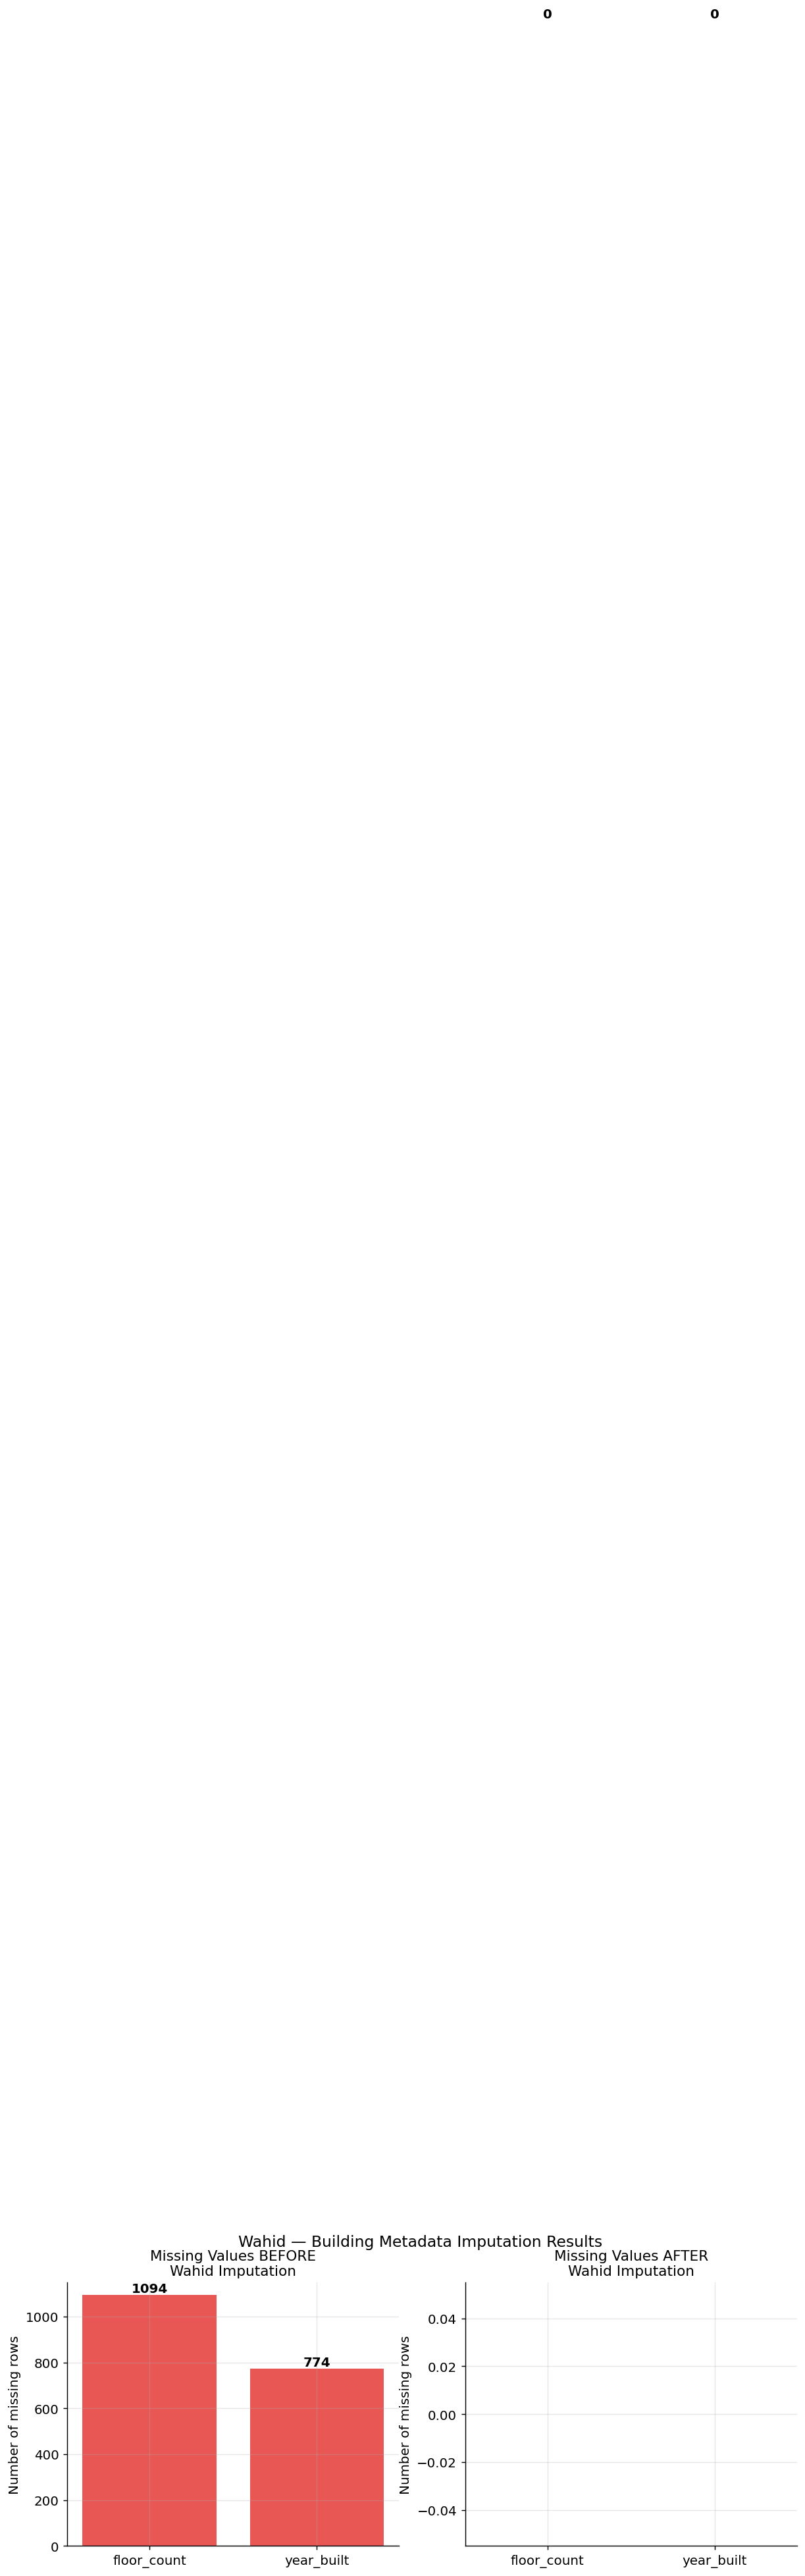

Wahid imputation plot saved. Now merging data...

Merging...
Merged shape: (20216100, 32)

Adding Shivalika time features...
Adding weather features...
Adding lag and rolling features — takes a few minutes...

Plotting Shivalika time series patterns...


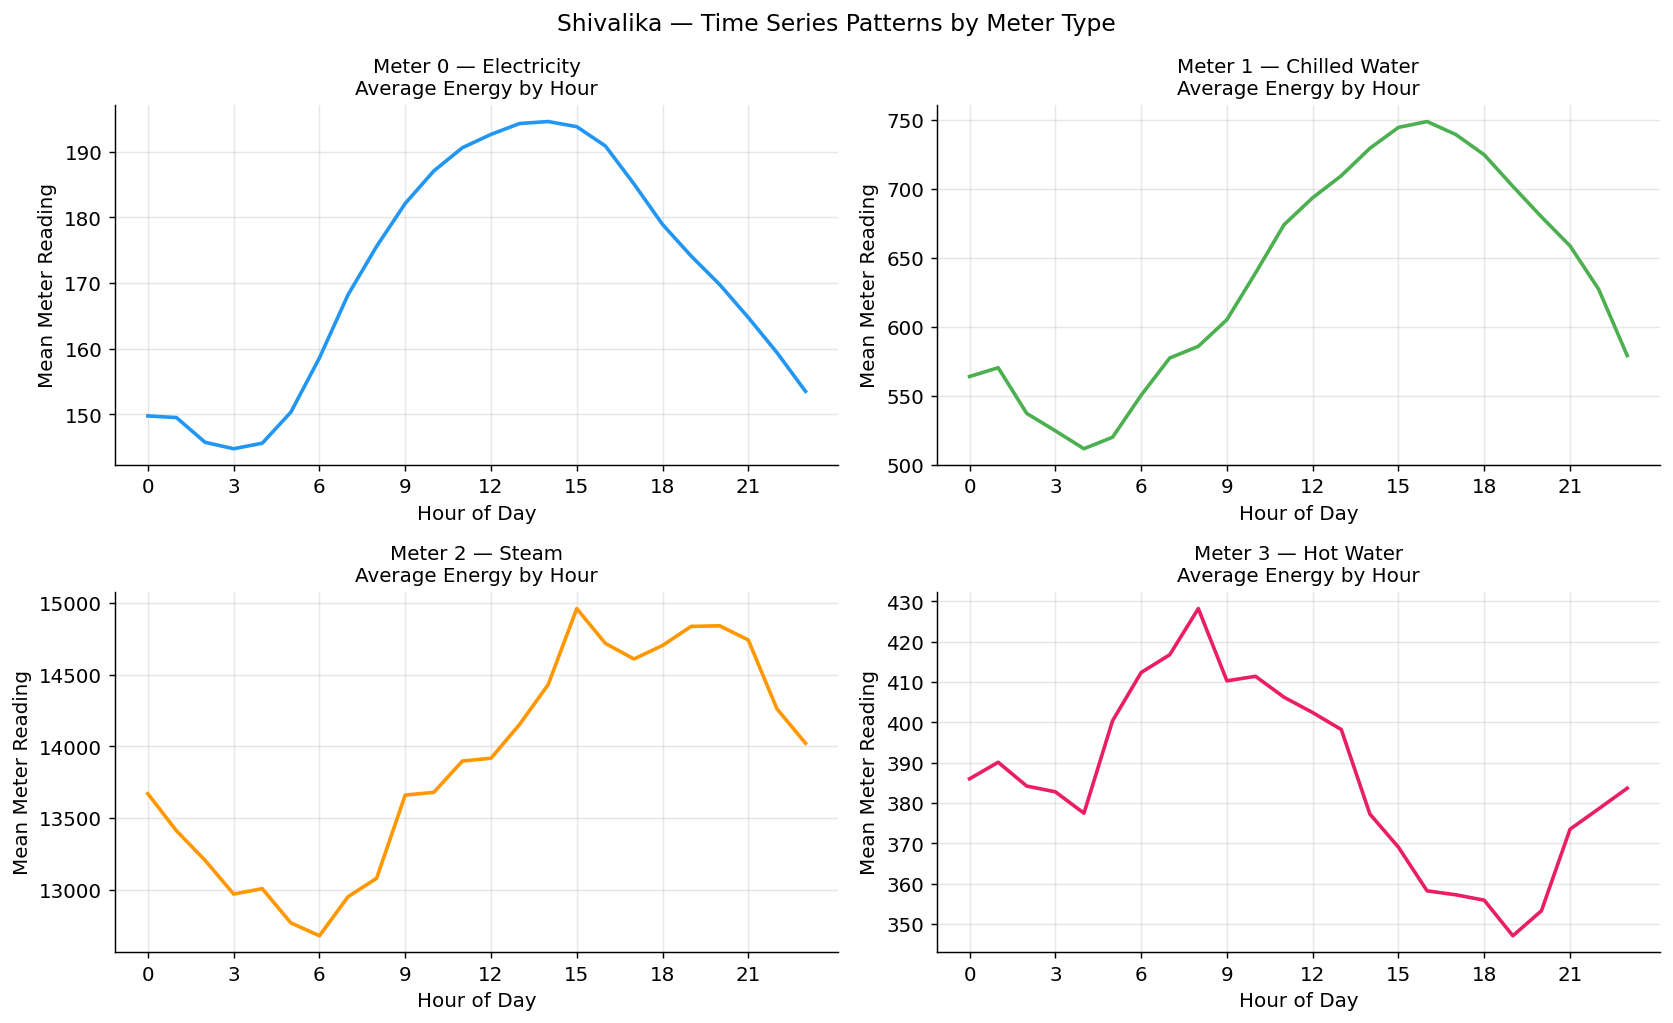

Shivalika time series plot saved. Now splitting data...

Splitting and saving...
Train saved: (16172880, 49)
Val saved  : (4043220, 49)

Preparing model features...
X_train: (16172880, 45)
X_test : (4043220, 45)
Ayan RMSLE function loaded.

Computing baseline...
Baseline RMSLE: 1.4649

Training LightGBM (Shivalika)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.550099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3558
[LightGBM] [Info] Number of data points in the train set: 16172880, number of used features: 44
[LightGBM] [Info] Start training from score 4.129124
LightGBM RMSLE: 0.5583
Plotting LightGBM scatter plot...


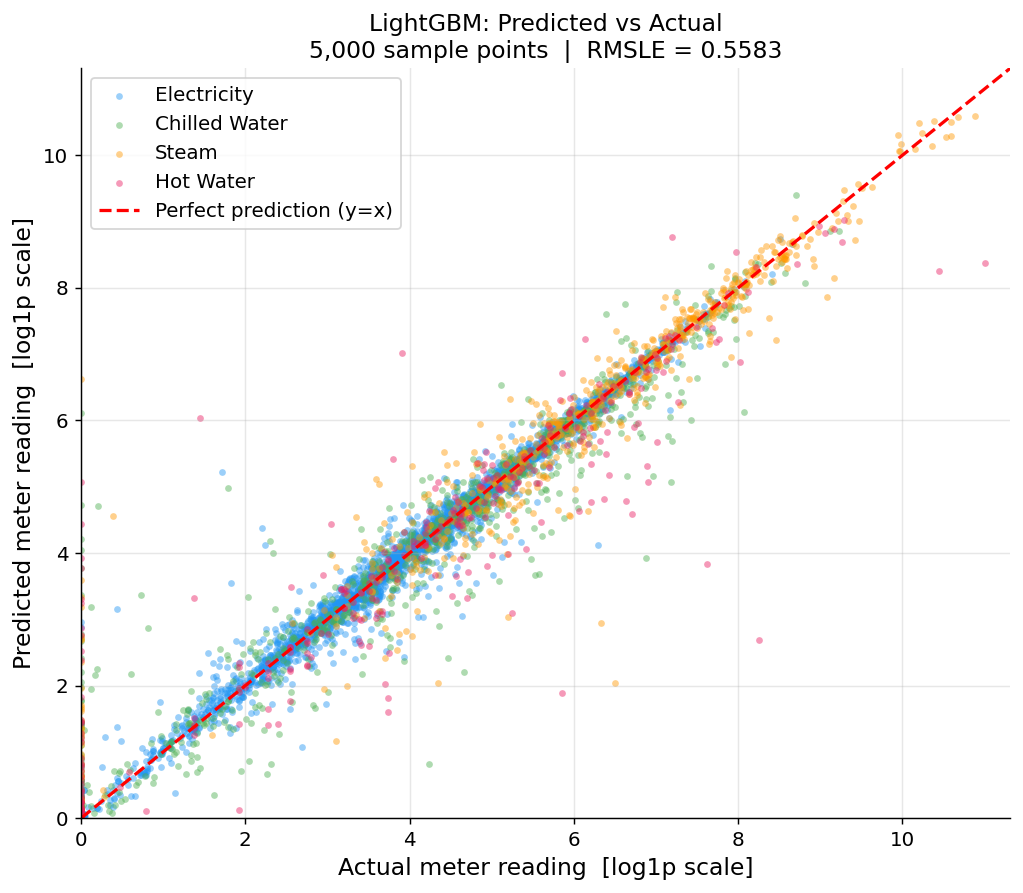

Scatter plot saved. Now starting Random Forest — please wait 5-10 mins...

Training Random Forest (Ayan)...
Random Forest RMSLE: 0.5774
Plotting RMSLE bar chart...

Meter              LightGBM   Rand Forest   Baseline
----------------------------------------------------
Electricity          0.2616        0.2620     0.7408
Chilled Water        0.7050        0.7413     2.1086
Steam                0.7983        0.8249     2.1131
Hot Water            1.1388        1.1716     2.1313


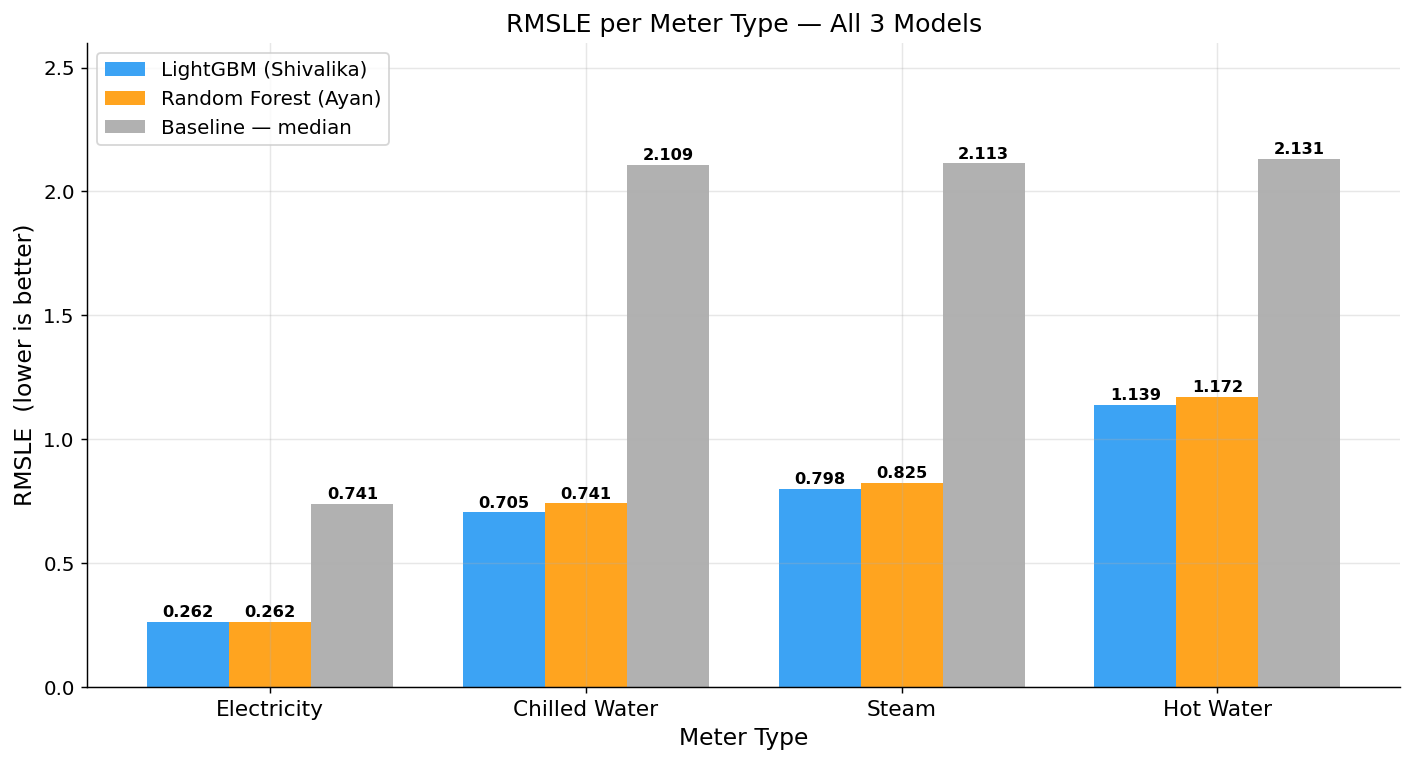

Bar chart saved.

  RMSLE VERIFICATION
  LightGBM (Shivalika) : 0.5583
  Random Forest (Ayan) : 0.5774
  Baseline             : 1.4649
  Re-check LightGBM      -> Consistent
  Re-check Random Forest -> Consistent

  FLAGS — copy into group chat
  [FLAG] LightGBM: 52156 negative predictions.

  LightGBM overall RMSLE : 0.5583
  Random Forest overall  : 0.5774
  Baseline overall       : 1.4649

All done! PNG files saved in your notebooks folder.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 11
})

METER_NAMES  = {0:'Electricity', 1:'Chilled Water', 2:'Steam', 3:'Hot Water'}
METER_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#E91E63'}

# ══════════════════════════════════════════════════════════════
# STEP 1 — LOAD RAW FILES
# ══════════════════════════════════════════════════════════════
print('Loading raw files...')
train_raw = pd.read_csv(r'C:\Users\TANISHA\OneDrive\Desktop\CMT307_GreatEnergyPredictor\data_processed\train.csv')
meta = pd.read_csv(r'C:\Users\TANISHA\OneDrive\Desktop\CMT307_GreatEnergyPredictor\data_processed\building_metadata.csv')
weather = pd.read_csv(r'C:\Users\TANISHA\OneDrive\Desktop\CMT307_GreatEnergyPredictor\data_processed\weather_train.csv')
print('train_raw:', train_raw.shape)
print('meta     :', meta.shape)
print('weather  :', weather.shape)

# ══════════════════════════════════════════════════════════════
# STEP 2 — WAHID'S BUILDING METADATA PREPROCESSING
# ══════════════════════════════════════════════════════════════
print('\nRunning Wahid building metadata preprocessing...')

meta['missing_floor_count_flag'] = meta['floor_count'].isna().astype(int)

meta['sqft_bin'] = pd.qcut(meta['square_feet'], q=5, duplicates='drop')
meta['floor_count'] = meta['floor_count'].fillna(
    meta.groupby(['primary_use','site_id','sqft_bin'], observed=True)['floor_count'].transform('median')
)
meta['floor_count'] = meta['floor_count'].fillna(
    meta.groupby(['primary_use','sqft_bin'], observed=True)['floor_count'].transform('median')
)
meta['floor_count'] = meta['floor_count'].fillna(
    meta.groupby('sqft_bin', observed=True)['floor_count'].transform('median')
)
meta['floor_count'] = meta['floor_count'].fillna(meta['floor_count'].median())
meta['floor_count'] = meta['floor_count'].round().astype(int)
meta = meta.drop(columns=['sqft_bin'])

meta['year_built'] = meta['year_built'].fillna(
    meta.groupby(['primary_use','site_id'], observed=True)['year_built'].transform('median')
)
meta['year_built'] = meta['year_built'].fillna(
    meta.groupby('primary_use', observed=True)['year_built'].transform('median')
)
meta['year_built'] = meta['year_built'].fillna(meta['year_built'].median())

meta['building_age']    = 2016 - meta['year_built']
meta['log_square_feet'] = np.log1p(meta['square_feet'])
meta = pd.get_dummies(meta, columns=['primary_use'], prefix='use')
meta.drop(columns=['year_built','square_feet'], inplace=True)

print('Wahid preprocessing done. Meta shape:', meta.shape)

# ── WAHID PLOT — Missing values before vs after imputation ───
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

before = {'floor_count': 1094, 'year_built': 774}
after  = {'floor_count': 0,    'year_built': 0}

axes[0].bar(before.keys(), before.values(), color='#E53935', alpha=0.85)
axes[0].set_title('Missing Values BEFORE\nWahid Imputation', fontsize=12)
axes[0].set_ylabel('Number of missing rows')
for i, (k, v) in enumerate(before.items()):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].bar(after.keys(), after.values(), color='#43A047', alpha=0.85)
axes[1].set_title('Missing Values AFTER\nWahid Imputation', fontsize=12)
axes[1].set_ylabel('Number of missing rows')
for i, (k, v) in enumerate(after.items()):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Wahid — Building Metadata Imputation Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('wahid_imputation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Wahid imputation plot saved. Now merging data...')

# ══════════════════════════════════════════════════════════════
# STEP 3 — MERGE
# ══════════════════════════════════════════════════════════════
print('\nMerging...')
train_raw['timestamp'] = pd.to_datetime(train_raw['timestamp'], format='mixed')
weather['timestamp']   = pd.to_datetime(weather['timestamp'],   format='mixed')

df = train_raw.merge(meta, on='building_id', how='left')
df = df.merge(weather, on=['site_id','timestamp'], how='left')
print('Merged shape:', df.shape)

# ══════════════════════════════════════════════════════════════
# STEP 4 — SHIVALIKA'S TIME FEATURES
# ══════════════════════════════════════════════════════════════
print('\nAdding Shivalika time features...')
df['hour']              = df['timestamp'].dt.hour
df['day_of_week']       = df['timestamp'].dt.dayofweek
df['is_weekend']        = df['day_of_week'].isin([5,6]).astype(int)
df['month']             = df['timestamp'].dt.month
df['day_of_year']       = df['timestamp'].dt.dayofyear
df['season']            = df['month'].map({12:0,1:0,2:0,3:1,4:1,5:1,
                                            6:2,7:2,8:2,9:3,10:3,11:3})
df['is_business_hours'] = df['hour'].between(8,18).astype(int)

# ══════════════════════════════════════════════════════════════
# STEP 5 — WEATHER FEATURES
# ══════════════════════════════════════════════════════════════
print('Adding weather features...')
for col in ['air_temperature','dew_temperature','wind_speed',
            'cloud_coverage','sea_level_pressure',
            'wind_direction','precip_depth_1_hr']:
    df[col] = df[col].fillna(df[col].median())

df['precip_was_missing']     = df['precip_depth_1_hr'].isna().astype(int)
df['relative_humidity']      = 100 - 5*(df['air_temperature'] - df['dew_temperature'])
df['temp_diff_from_comfort'] = (df['air_temperature'] - 21).abs()

# ══════════════════════════════════════════════════════════════
# STEP 6 — SHIVALIKA'S LAG AND ROLLING FEATURES
# ══════════════════════════════════════════════════════════════
print('Adding lag and rolling features — takes a few minutes...')
df = df.sort_values(['building_id','meter','timestamp'])

for lag in [24, 72, 168]:
    df[f'lag_{lag}h'] = (
        df.groupby(['building_id','meter'])['meter_reading']
        .shift(lag).fillna(0)
    )

df['rolling_mean_24h'] = (
    df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(24, min_periods=1).mean()).fillna(0)
)
df['rolling_std_24h'] = (
    df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(24, min_periods=1).std()).fillna(0)
)
df['rolling_mean_168h'] = (
    df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(168, min_periods=1).mean()).fillna(0)
)
df['log_meter_reading'] = np.log1p(df['meter_reading'])

# ── SHIVALIKA PLOT — Average energy by hour per meter type ───
print('\nPlotting Shivalika time series patterns...')
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
for i, m_id in enumerate([0,1,2,3]):
    subset = df[df['meter'] == m_id]
    if len(subset) == 0:
        continue
    hourly = subset.groupby('hour')['meter_reading'].mean()
    axes[i].plot(hourly.index, hourly.values, color=METER_COLORS[m_id], lw=2)
    axes[i].set_title(f'Meter {m_id} — {METER_NAMES[m_id]}\nAverage Energy by Hour', fontsize=11)
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('Mean Meter Reading')
    axes[i].set_xticks(range(0,24,3))
plt.suptitle('Shivalika — Time Series Patterns by Meter Type', fontsize=13)
plt.tight_layout()
plt.savefig('shivalika_time_series_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Shivalika time series plot saved. Now splitting data...')

# ══════════════════════════════════════════════════════════════
# STEP 7 — TRAIN / VAL SPLIT AND SAVE
# ══════════════════════════════════════════════════════════════
print('\nSplitting and saving...')
df = df.sort_values('timestamp').reset_index(drop=True)
split    = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
val_df   = df.iloc[split:].copy()

save_path = r'C:\Users\TANISHA\OneDrive\Desktop\CMT307_GreatEnergyPredictor\data_processed'
os.makedirs(save_path, exist_ok=True)
train_df.to_csv(os.path.join(save_path, 'final_train_with_features.csv'), index=False)
val_df.to_csv(  os.path.join(save_path, 'final_val_with_features.csv'),   index=False)
print(f'Train saved: {train_df.shape}')
print(f'Val saved  : {val_df.shape}')

# ══════════════════════════════════════════════════════════════
# STEP 8 — PREPARE FEATURES
# ══════════════════════════════════════════════════════════════
print('\nPreparing model features...')
drop_cols = [c for c in ['meter_reading','log_meter_reading','timestamp','building_id']
             if c in train_df.columns]

X_train   = train_df.drop(columns=drop_cols)
y_train   = train_df['log_meter_reading']
X_test    = val_df.drop(columns=drop_cols)
X_test    = X_test.reindex(columns=X_train.columns, fill_value=0)
y_true    = val_df['meter_reading'].values
meter_col = val_df['meter'].values
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

# ══════════════════════════════════════════════════════════════
# STEP 9 — AYAN'S RMSLE FUNCTION
# ══════════════════════════════════════════════════════════════
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

print('Ayan RMSLE function loaded.')

# ══════════════════════════════════════════════════════════════
# STEP 10 — BASELINE (Ayan Sprint 2)
# ══════════════════════════════════════════════════════════════
print('\nComputing baseline...')
train_df['_hour'] = train_df['timestamp'].dt.hour
train_df['_dow']  = train_df['timestamp'].dt.dayofweek
val_df['_hour']   = val_df['timestamp'].dt.hour
val_df['_dow']    = val_df['timestamp'].dt.dayofweek

baseline_median = (
    train_df.groupby(['building_id','meter','_hour','_dow'])['meter_reading']
    .median().reset_index().rename(columns={'meter_reading':'pred'})
)
test_b = val_df[['building_id','meter','_hour','_dow']].copy()
test_b = test_b.merge(baseline_median, on=['building_id','meter','_hour','_dow'], how='left')
test_b['pred']  = test_b['pred'].fillna(train_df['meter_reading'].median())
y_pred_baseline = test_b['pred'].values
rmsle_baseline  = rmsle(y_true, y_pred_baseline)
print(f'Baseline RMSLE: {rmsle_baseline:.4f}')

# ══════════════════════════════════════════════════════════════
# STEP 11 — LIGHTGBM (Shivalika)
# ══════════════════════════════════════════════════════════════
print('\nTraining LightGBM (Shivalika)...')
y_train_log = np.log1p(train_df['meter_reading'])
lgbm_model  = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=31, random_state=42, n_jobs=-1
)
lgbm_model.fit(X_train, y_train_log)
y_pred_lgbm = np.expm1(lgbm_model.predict(X_test))
rmsle_lgbm  = rmsle(y_true, y_pred_lgbm)
print(f'LightGBM RMSLE: {rmsle_lgbm:.4f}')

# ── PLOT IMMEDIATELY after LightGBM — Scatter plot ───────────
print('Plotting LightGBM scatter plot...')
rng        = np.random.default_rng(seed=42)
idx        = rng.choice(len(y_true), size=5000, replace=False)
actual_log = np.log1p(y_true[idx])
pred_log   = np.log1p(y_pred_lgbm[idx])
m_sample   = meter_col[idx]

fig, ax = plt.subplots(figsize=(8, 7))
for m_id, m_name in METER_NAMES.items():
    mask = m_sample == m_id
    if mask.sum() == 0:
        continue
    ax.scatter(actual_log[mask], pred_log[mask],
               c=METER_COLORS[m_id], label=m_name, alpha=0.45, s=14, linewidths=0)
max_val = max(actual_log.max(), pred_log.max()) + 0.3
ax.plot([0, max_val], [0, max_val], color='red', lw=1.8,
        linestyle='--', label='Perfect prediction (y=x)')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel('Actual meter reading  [log1p scale]', fontsize=13)
ax.set_ylabel('Predicted meter reading  [log1p scale]', fontsize=13)
ax.set_title(f'LightGBM: Predicted vs Actual\n5,000 sample points  |  RMSLE = {rmsle_lgbm:.4f}',
             fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('scatter_lightgbm_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plot saved. Now starting Random Forest — please wait 5-10 mins...')

# ══════════════════════════════════════════════════════════════
# STEP 12 — RANDOM FOREST (Ayan)
# ══════════════════════════════════════════════════════════════
print('\nTraining Random Forest (Ayan)...')
rf_model = RandomForestRegressor(
    n_estimators=400, max_depth=20,
    min_samples_split=6, min_samples_leaf=4,
    max_features='log2', n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = np.expm1(rf_model.predict(X_test))
rmsle_rf  = rmsle(y_true, y_pred_rf)
print(f'Random Forest RMSLE: {rmsle_rf:.4f}')

# ── PLOT IMMEDIATELY after RF — Bar chart all 3 models ───────
print('Plotting RMSLE bar chart...')
meter_ids    = sorted(np.unique(meter_col))
meter_labels = [METER_NAMES.get(m, f'Meter {m}') for m in meter_ids]
lgbm_per_m, rf_per_m, base_per_m = [], [], []

for m_id in meter_ids:
    mask = meter_col == m_id
    lgbm_per_m.append(rmsle(y_true[mask], y_pred_lgbm[mask]))
    rf_per_m.append(  rmsle(y_true[mask], y_pred_rf[mask]))
    base_per_m.append(rmsle(y_true[mask], y_pred_baseline[mask]))

print(f'\n{"Meter":<16} {"LightGBM":>10} {"Rand Forest":>13} {"Baseline":>10}')
print('-' * 52)
for i, name in enumerate(meter_labels):
    print(f'{name:<16} {lgbm_per_m[i]:>10.4f} {rf_per_m[i]:>13.4f} {base_per_m[i]:>10.4f}')

x, w = np.arange(len(meter_labels)), 0.26
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x-w, lgbm_per_m, w, label='LightGBM (Shivalika)', color='#2196F3', alpha=0.88)
b2 = ax.bar(x,   rf_per_m,   w, label='Random Forest (Ayan)', color='#FF9800', alpha=0.88)
b3 = ax.bar(x+w, base_per_m, w, label='Baseline — median',    color='#9E9E9E', alpha=0.80)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h+0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Meter Type', fontsize=13)
ax.set_ylabel('RMSLE  (lower is better)', fontsize=13)
ax.set_title('RMSLE per Meter Type — All 3 Models', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(meter_labels, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(lgbm_per_m + rf_per_m + base_per_m) * 1.22)
plt.tight_layout()
plt.savefig('rmsle_per_meter_type_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart saved.')

# ══════════════════════════════════════════════════════════════
# STEP 13 — VERIFICATION + FLAGS
# ══════════════════════════════════════════════════════════════
print()
print('=' * 60)
print('  RMSLE VERIFICATION')
print('=' * 60)
print(f'  LightGBM (Shivalika) : {rmsle_lgbm:.4f}')
print(f'  Random Forest (Ayan) : {rmsle_rf:.4f}')
print(f'  Baseline             : {rmsle_baseline:.4f}')
ok1 = np.isclose(rmsle(y_true, y_pred_lgbm), rmsle_lgbm)
ok2 = np.isclose(rmsle(y_true, y_pred_rf),   rmsle_rf)
print(f'  Re-check LightGBM      -> {"Consistent" if ok1 else "MISMATCH"}')
print(f'  Re-check Random Forest -> {"Consistent" if ok2 else "MISMATCH"}')
print('=' * 60)

print()
print('=' * 62)
print('  FLAGS — copy into group chat')
print('=' * 62)
flags = []
for i, name in enumerate(meter_labels):
    if base_per_m[i] < lgbm_per_m[i]:
        flags.append(f'[FLAG] {name}: Baseline < LightGBM — LightGBM worse than mean!')
    if base_per_m[i] < rf_per_m[i]:
        flags.append(f'[FLAG] {name}: Baseline < RF — RF worse than mean!')
    for mname, score in [('LightGBM', lgbm_per_m[i]), ('RF', rf_per_m[i])]:
        if score > 1.5:
            flags.append(f'[FLAG] {name} {mname} RMSLE = {score:.3f} — very high.')
for mname, preds in [('LightGBM', y_pred_lgbm), ('RF', y_pred_rf)]:
    if (preds < 0).sum() > 0:
        flags.append(f'[FLAG] {mname}: {(preds<0).sum()} negative predictions.')
    if (preds > 1_000_000).sum() > 0:
        flags.append(f'[FLAG] {mname}: {(preds>1_000_000).sum()} predictions over 1M kWh.')
if flags:
    for f in flags:
        print(f'  {f}')
else:
    print('  No suspicious results. Both models beat baseline on all meter types.')
print('=' * 62)
print(f'\n  LightGBM overall RMSLE : {rmsle_lgbm:.4f}')
print(f'  Random Forest overall  : {rmsle_rf:.4f}')
print(f'  Baseline overall       : {rmsle_baseline:.4f}')
print('\nAll done! PNG files saved in your notebooks folder.')